# Quantum Computation — Assignment 2

**Albert Kabore**  
PhD student in Advanced and Equitable Computing

**Single-qubit states and the Pauli / Hadamard gates in Qiskit**

This notebook contains all the code for the assignment:

1. **Question 1** – numerically verify that
$|\psi\rangle = \frac{i}{2}|0\rangle + \frac{\sqrt{3}\,e^{i\pi/6}}{2}|1\rangle$ is normalised.
2. **Question 2** – build, draw, simulate and measure the circuits $H|0\rangle$, $Y|0\rangle$ and $Z|0\rangle$,
then compare the measured histograms with the mathematically predicted probabilities $P(|0\rangle)$ and $P(|1\rangle)$.

All figures are saved to the `figures/` folder so they can be inserted in the report.

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

import qiskit
import qiskit_aer
from IPython.display import display
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

os.makedirs("figures", exist_ok=True)
SHOTS = 1024     # number of repetitions of each experiment
SEED = 42        # fixed seed so the results are reproducible

print("Qiskit version:", qiskit.__version__)
print("Qiskit Aer version:", qiskit_aer.__version__)
print("Python executable:", sys.executable)
print("Python version:", sys.version.split()[0])

Qiskit version: 2.5.2
Qiskit Aer version: 0.17.2
Python executable: C:\Users\alber\Quantum-Computation_Assignment_2\.venv311\Scripts\python.exe
Python version: 3.11.0


## Question 1 — Normalisation of $|\psi\rangle$

A single-qubit state $|\psi\rangle = a_0|0\rangle + a_1|1\rangle$ is valid when

$$\langle\psi|\psi\rangle = |a_0|^2 + |a_1|^2 = 1 .$$

Here $a_0 = \dfrac{i}{2}$ and $a_1 = \dfrac{\sqrt{3}\,e^{i\pi/6}}{2}$.

By hand: $|a_0|^2 = \frac{i}{2}\cdot\frac{-i}{2} = \frac14$, and
$|a_1|^2 = \frac{3}{4}\,e^{i\pi/6}e^{-i\pi/6} = \frac34$, so $|a_0|^2+|a_1|^2 = 1$. ✔

The cell below checks this numerically.

For a new learner: $|0\rangle=(1,0)^T$ and $|1\rangle=(0,1)^T$ are perpendicular unit vectors. The superscript $T$ means transpose, so these are column vectors. The coefficients $a_0,a_1$ are complex **amplitudes**, not probabilities. The Born rule gives the computational-basis measurement probabilities $P(0)=|a_0|^2$ and $P(1)=|a_1|^2$.

For a complex number $z=x+iy$, $i^2=-1$, its conjugate is $z^*=x-iy$, and $|z|^2=z^*z=x^2+y^2$. Also $|e^{i\theta}|=1$. These explain why the phases disappear when calculating the two probabilities above. The cross terms in $\langle\psi|\psi\rangle$ vanish because $\langle0|1\rangle=\langle1|0\rangle=0$.

Thus $\|\psi\|=\sqrt{\langle\psi|\psi\rangle}=\sqrt{1}=1$: both the squared norm and the norm are one. This proves that the given ket is a valid state vector. Measuring it would give 0 with probability $1/4$ and 1 with probability $3/4$.


In [2]:
a0 = 1j / 2
a1 = np.sqrt(3) * np.exp(1j * np.pi / 6) / 2

print(f"a0 = {a0:.4f}")
print(f"a1 = {a1:.4f}   (= 3/4 + i*sqrt(3)/4 in Cartesian form)")
print(f"|a0|^2 = {abs(a0)**2:.4f}")
print(f"|a1|^2 = {abs(a1)**2:.4f}")
norm_sq = abs(a0)**2 + abs(a1)**2
print(f"|a0|^2 + |a1|^2 = {norm_sq:.4f}")

psi = Statevector([a0, a1])
print("Qiskit Statevector.is_valid():", psi.is_valid())
assert np.isclose(norm_sq, 1.0)

a0 = 0.0000+0.5000j
a1 = 0.7500+0.4330j   (= 3/4 + i*sqrt(3)/4 in Cartesian form)
|a0|^2 = 0.2500
|a1|^2 = 0.7500
|a0|^2 + |a1|^2 = 1.0000
Qiskit Statevector.is_valid(): True


## Question 2 — Helper function

For every circuit we:

1. create `qc = QuantumCircuit(1, 1)` (1 qubit, 1 classical bit) — the qubit starts in $|0\rangle$;
2. apply the gate;
3. read the **exact** output state with `Statevector` (this independently checks the hand derivations below, *before* measurement);
4. add a measurement, `draw()` the circuit, run it on the `AerSimulator` for 1024 shots and plot the histogram.

A **shot** repeats the entire circuit from a freshly prepared $|0\rangle$ state; it is not another measurement of the same collapsed state. The measurement box records 0 or 1 on the classical wire. We use an ideal simulator with no noise model. `transpile` translates the circuit into operations supported by the simulator. The displayed histogram heights are counts. Dividing each count by SHOTS gives a relative frequency, an estimate of the exact probability. The H gate is the Hadamard gate; X, Y, and Z are the Pauli gates. Only H, Y, and Z are required here.

In [3]:
simulator = AerSimulator()

def run_single_qubit_circuit(gate_name):
    # 1) circuit with 1 qubit and 1 classical bit, qubit initialised to |0>
    qc = QuantumCircuit(1, 1)

    # 2) apply the requested gate using Qiskit's syntax
    getattr(qc, gate_name)(0)          # qc.h(0), qc.x(0), qc.y(0) or qc.z(0)

    # 3) exact state vector before measurement (theory)
    state = Statevector.from_instruction(qc)
    probs = state.probabilities_dict()

    # 4) measure qubit 0 into classical bit 0
    qc.measure(0, 0)

    # draw the circuit (text in the notebook + image for the report)
    print(qc.draw())
    fig_c = qc.draw("mpl")
    fig_c.savefig(f"figures/circuit_{gate_name}.png", dpi=200, bbox_inches="tight")
    display(fig_c)
    plt.close(fig_c)

    # simulate
    job = simulator.run(transpile(qc, simulator, seed_transpiler=SEED), shots=SHOTS, seed_simulator=SEED)
    counts = job.result().get_counts()
    counts = {k: counts.get(k, 0) for k in ("0", "1")}  # show both outcomes

    fig_h = plot_histogram(counts, title=f"{gate_name.upper()}|0>  ({SHOTS} shots)",
                           figsize=(6, 4))
    fig_h.savefig(f"figures/histogram_{gate_name}.png", dpi=200, bbox_inches="tight")
    display(fig_h)
    plt.close(fig_h)

    print("Statevector:", np.round(state.data, 4))
    print("Predicted  P(0) = %.4f   P(1) = %.4f" % (probs.get("0", 0), probs.get("1", 0)))
    print("Observed   f(0) = %.4f   f(1) = %.4f   counts = %s"
          % (counts["0"] / SHOTS, counts["1"] / SHOTS, counts))
    return qc, state, counts

## (a) $H|0\rangle$

$$H = \frac{1}{\sqrt2}\begin{pmatrix}1&1\\1&-1\end{pmatrix},\qquad
H|0\rangle = \frac{1}{\sqrt2}\begin{pmatrix}1\\1\end{pmatrix} = \frac{|0\rangle+|1\rangle}{\sqrt2} = |+\rangle$$

Prediction: $P(|0\rangle) = \left|\tfrac{1}{\sqrt2}\right|^2 = 0.5$, $P(|1\rangle) = 0.5$ → roughly 512 counts each.

To see the matrix multiplication explicitly (each row times the input column):

$$H|0\rangle=\frac{1}{\sqrt2}\begin{pmatrix}1&1\\1&-1\end{pmatrix}\begin{pmatrix}1\\0\end{pmatrix}=\frac{1}{\sqrt2}\begin{pmatrix}1\cdot1+1\cdot0\\1\cdot1+(-1)\cdot0\end{pmatrix}$$

     ┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 


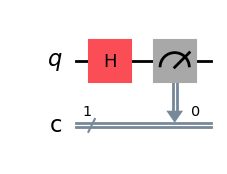

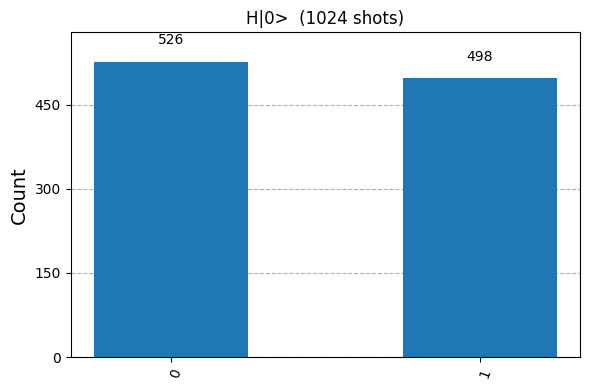

Statevector: [0.7071+0.j 0.7071+0.j]
Predicted  P(0) = 0.5000   P(1) = 0.5000
Observed   f(0) = 0.5137   f(1) = 0.4863   counts = {'0': 526, '1': 498}


In [4]:
qc_h, state_h, counts_h = run_single_qubit_circuit("h")

## (b) $Y|0\rangle$

$$Y = \begin{pmatrix}0&-i\\ i&0\end{pmatrix},\qquad
Y|0\rangle = \begin{pmatrix}0\\ i\end{pmatrix} = i|1\rangle$$

Prediction: $P(|0\rangle) = 0$, $P(|1\rangle) = |i|^2 = 1$ → all 1024 counts in `1`.
(The factor $i$ is a *global phase* and cannot be seen by a measurement.)

To see the matrix multiplication explicitly (each row times the input column):

$$Y|0\rangle=\begin{pmatrix}0&-i\\i&0\end{pmatrix}\begin{pmatrix}1\\0\end{pmatrix}=\begin{pmatrix}0\cdot1+(-i)\cdot0\\i\cdot1+0\cdot0\end{pmatrix}$$

     ┌───┐┌─┐
  q: ┤ Y ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 


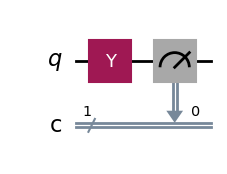

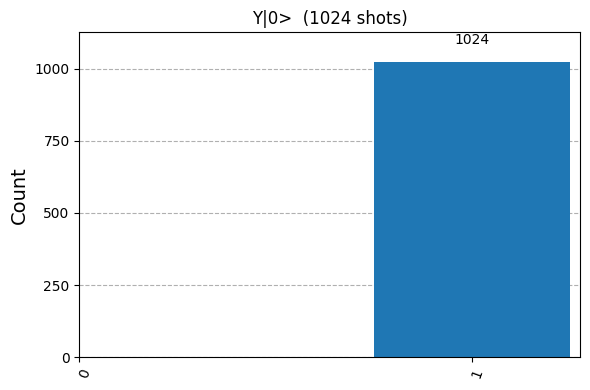

Statevector: [0.+0.j 0.+1.j]
Predicted  P(0) = 0.0000   P(1) = 1.0000
Observed   f(0) = 0.0000   f(1) = 1.0000   counts = {'0': 0, '1': 1024}


In [5]:
qc_y, state_y, counts_y = run_single_qubit_circuit("y")

## (c) $Z|0\rangle$

$$Z = \begin{pmatrix}1&0\\0&-1\end{pmatrix},\qquad
Z|0\rangle = \begin{pmatrix}1\\0\end{pmatrix} = |0\rangle$$

Prediction: $P(|0\rangle) = 1$, $P(|1\rangle) = 0$ → all 1024 counts in `0`.

To see the matrix multiplication explicitly (each row times the input column):

$$Z|0\rangle=\begin{pmatrix}1&0\\0&-1\end{pmatrix}\begin{pmatrix}1\\0\end{pmatrix}=\begin{pmatrix}1\cdot1+0\cdot0\\0\cdot1+(-1)\cdot0\end{pmatrix}$$

Z changes the sign of the $|1\rangle$ amplitude, but here that amplitude is zero. In a superposition, that sign can change a **relative phase**, which can affect later interference. For example, $HZH|0\rangle=|1\rangle$, whereas $HH|0\rangle=|0\rangle$. Thus computational-basis histograms alone cannot verify phases or uniquely identify a state vector. The factor $i$ in $Y|0\rangle=i|1\rangle$ is a **global phase** (it multiplies the whole state) and has no observable effect.


     ┌───┐┌─┐
  q: ┤ Z ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 


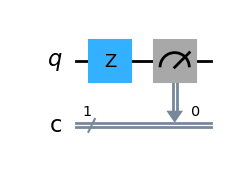

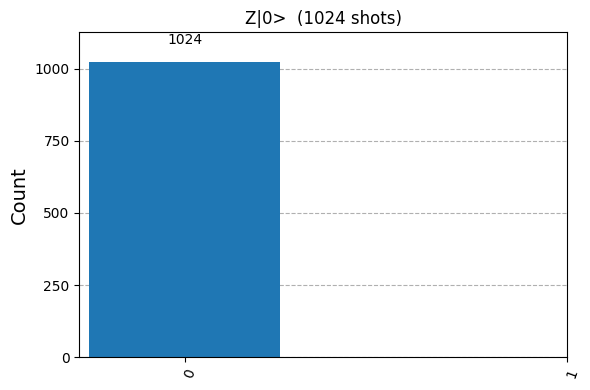

Statevector: [1.+0.j 0.+0.j]
Predicted  P(0) = 1.0000   P(1) = 0.0000
Observed   f(0) = 1.0000   f(1) = 0.0000   counts = {'0': 1024, '1': 0}


In [6]:
qc_z, state_z, counts_z = run_single_qubit_circuit("z")

## Verification — prediction vs. Qiskit measurement

The hand-derived states and probabilities are checked separately from sampled counts. For H, the expected count of zeros is $Np=1024/2=512$, with standard deviation $\sqrt{Np(1-p)}=16$ counts. The observed 526 differs by 14 counts, or 0.875 standard deviations, which is consistent with the prediction. The standard deviation of the relative frequency is $\sqrt{p(1-p)/N}=0.015625$. Increasing shots reduces this typical uncertainty; it does not guarantee every larger run is closer to 50/50.

The three-standard-deviation comparison below is a statistical consistency check, not a proof: a correct random sample can occasionally lie outside that range. The fixed seed reproduces this run in the tested software environment; exact sampled counts can differ across software versions.


In [7]:
rows = [("H|0>", state_h, counts_h), ("Y|0>", state_y, counts_y), ("Z|0>", state_z, counts_z)]

print(f"{'Circuit':<8}{'Pred P(0)':>11}{'Pred P(1)':>11}{'Obs f(0)':>11}{'Obs f(1)':>11}{'Counts':>22}")
for name, st, cnt in rows:
    p = st.probabilities_dict()
    print(f"{name:<8}{p.get('0',0):>11.3f}{p.get('1',0):>11.3f}"
          f"{cnt['0']/SHOTS:>11.3f}{cnt['1']/SHOTS:>11.3f}{str(cnt):>22}")

# Compare against the independently hand-derived amplitudes and probabilities.
expected = [(state_h, [1 / np.sqrt(2), 1 / np.sqrt(2)], [0.5, 0.5]),
            (state_y, [0, 1j], [0, 1]),
            (state_z, [1, 0], [1, 0])]
for state, amplitudes, probabilities in expected:
    assert np.allclose(state.data, amplitudes)
    assert np.allclose(state.probabilities(), probabilities)
    assert state.is_valid()
for _, _, counts in rows:
    assert sum(counts.values()) == SHOTS

# deterministic cases must match exactly; H must be within statistical tolerance (~3 sigma = 0.047)
assert counts_y == {"0": 0, "1": SHOTS}
assert counts_z == {"0": SHOTS, "1": 0}
assert abs(counts_h["0"] / SHOTS - 0.5) < 3 * np.sqrt(0.25 / SHOTS)
print("\nExact states match the hand derivations; sampled histograms are consistent with the predictions.")

Circuit   Pred P(0)  Pred P(1)   Obs f(0)   Obs f(1)                Counts
H|0>          0.500      0.500      0.514      0.486  {'0': 526, '1': 498}
Y|0>          0.000      1.000      0.000      1.000   {'0': 0, '1': 1024}
Z|0>          1.000      0.000      1.000      0.000   {'0': 1024, '1': 0}

Exact states match the hand derivations; sampled histograms are consistent with the predictions.


### Bonus — the X gate
This optional example is not required by parts (a)-(c). The assignment also lists `qc.x(0)`. For completeness:
$X = \begin{pmatrix}0&1\\1&0\end{pmatrix}$, so $X|0\rangle = |1\rangle$ and $P(|1\rangle)=1$.

     ┌───┐┌─┐
  q: ┤ X ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 


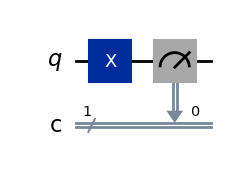

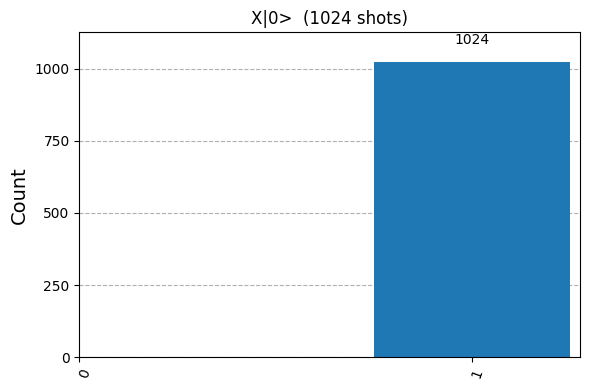

Statevector: [0.+0.j 1.+0.j]
Predicted  P(0) = 0.0000   P(1) = 1.0000
Observed   f(0) = 0.0000   f(1) = 1.0000   counts = {'0': 0, '1': 1024}


In [8]:
qc_x, state_x, counts_x = run_single_qubit_circuit("x")

## Assignment checklist and report

- Question 1: hand proof and numerical check of normalization.
- Question 2(a)-(c): hand-derived output states and both probabilities; executed Qiskit circuits; inline circuit and histogram output images; comparison with measurement frequencies.
- One document containing all answers: `Assignment2_Report_Final.docx`.

The Word report includes three generated Qiskit circuit diagrams and three simulated measurement histograms for H, Y, and Z, together with the code, mathematical derivations, probabilities, and verification. Figures are exported directly from Qiskit/Matplotlib; no screenshots are included.

References: [IBM single systems lesson](https://learning.quantum.ibm.com/course/basics-of-quantum-information/single-systems), [Qiskit visualization](https://quantum.cloud.ibm.com/docs/en/api/qiskit/visualization), [AerSimulator](https://qiskit.github.io/qiskit-aer/stubs/qiskit_aer.AerSimulator.html).
